<a href="https://colab.research.google.com/github/gunaanand08/Ioe/blob/main/experiment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Temperature  Humidity  Pressure  Gas  Light
0         27.5        65    1012.6  212    325
1         27.9        64    1012.8  215    338
2         27.6        66    1012.5  213    332
3         28.2        63    1013.0  218    350
4         27.8        65    1012.7  216    345
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  25 non-null     float64
 1   Humidity     25 non-null     int64  
 2   Pressure     25 non-null     float64
 3   Gas          25 non-null     int64  
 4   Light        25 non-null     int64  
dtypes: float64(2), int64(3)
memory usage: 1.1 KB
None
Temperature    0
Humidity       0
Pressure       0
Gas            0
Light          0
dtype: int64
   Temperature  Humidity  Pressure       Gas     Light
0     0.000000  0.923077  0.058824  0.000000  0.000000
1     0.137931  0.846154  0.176471  0.100000  0.086667
2   

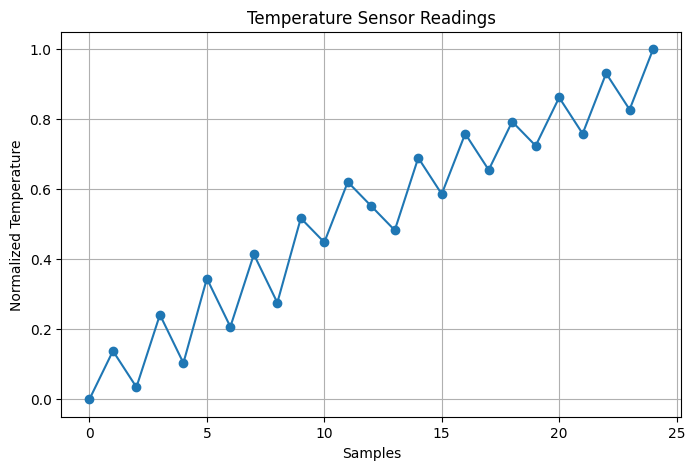

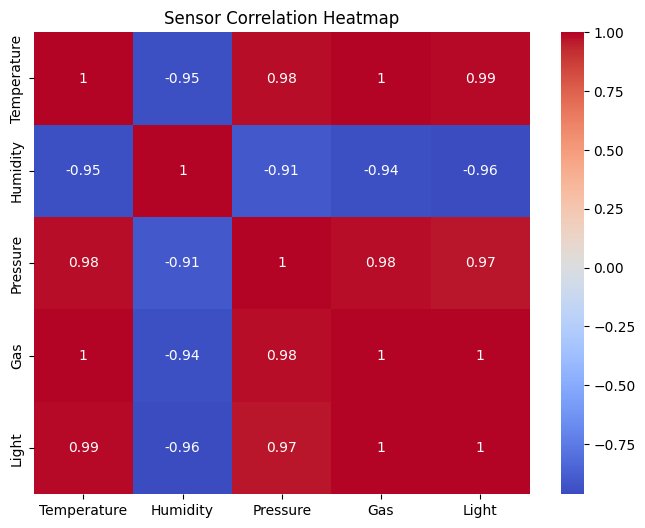

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

# Create Dataset (Realistic Sensor Readings)

data = {
    "Temperature": [
        27.5, 27.9, 27.6, 28.2, 27.8,
        28.5, 28.1, 28.7, 28.3, 29.0,
        28.8, 29.3, 29.1, 28.9, 29.5,
        29.2, 29.7, 29.4, 29.8, 29.6,
        30.0, 29.7, 30.2, 29.9, 30.4
    ],

    "Humidity": [
        65, 64, 66, 63, 65,
        62, 64, 61, 63, 60,
        61, 59, 60, 58, 59,
        57, 58, 56, 57, 55,
        56, 54, 55, 53, 54
    ],

    "Pressure": [
        1012.6, 1012.8, 1012.5, 1013.0, 1012.7,
        1013.2, 1012.9, 1013.3, 1013.1, 1013.5,
        1013.2, 1013.6, 1013.4, 1013.1, 1013.7,
        1013.4, 1013.8, 1013.5, 1013.9, 1013.6,
        1014.0, 1013.8, 1014.1, 1013.9, 1014.2
    ],

    "Gas": [
        212, 215, 213, 218, 216,
        221, 219, 224, 222, 227,
        225, 230, 228, 226, 232,
        229, 234, 231, 236, 233,
        238, 235, 240, 237, 242
    ],

    "Light": [
        325, 338, 332, 350, 345,
        365, 358, 380, 372, 395,
        388, 410, 402, 398, 420,
        415, 435, 428, 445, 438,
        455, 448, 465, 458, 475
    ]
}

df = pd.DataFrame(data)

# Display Dataset

print(df.head())

# Dataset Information

print(df.info())

# Missing Values

print(df.isnull().sum())

# Fill Missing Values

df.fillna(df.mean(numeric_only=True), inplace=True)

# Remove Duplicates

df.drop_duplicates(inplace=True)

# Normalize Numeric Columns

scaler = MinMaxScaler()

num_cols = df.select_dtypes(include=np.number).columns

df[num_cols] = scaler.fit_transform(df[num_cols])

# Display Cleaned Dataset

print(df.head())

# Save Dataset

df.to_csv("clean_sensor_data.csv", index=False)

# Plot Temperature

plt.figure(figsize=(8,5))
plt.plot(df['Temperature'], marker='o')
plt.title("Temperature Sensor Readings")
plt.xlabel("Samples")
plt.ylabel("Normalized Temperature")
plt.grid(True)
plt.show()

# Correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Sensor Correlation Heatmap")
plt.show()